In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [7]:
df=pd.read_excel('EastWestAirlines.xlsx', sheet_name="data")

In [8]:
df.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


In [92]:
df.drop('ID#',axis=1)

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,cluster,dbscan_cluster
0,28143,0,1,1,1,174,1,0,0,7000,0,2,-1
1,19244,0,1,1,1,215,2,0,0,6968,0,2,-1
2,41354,0,1,1,1,4123,4,0,0,7034,0,2,-1
3,14776,0,1,1,1,500,1,0,0,6952,0,2,-1
4,97752,0,4,1,1,43300,26,2077,4,6935,1,1,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3994,18476,0,1,1,1,8525,4,200,1,1403,1,0,-1
3995,64385,0,1,1,1,981,5,0,0,1395,1,0,-1
3996,73597,0,3,1,1,25447,8,0,0,1402,1,0,-1
3997,54899,0,1,1,1,500,1,500,1,1401,0,0,-1


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


In [5]:
df.describe()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3999.000000,3.999000e+03,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000,3999.000000
mean,2014.819455,7.360133e+04,144.114529,2.059515,1.014504,1.012253,17144.846212,11.60190,460.055764,1.373593,4118.55939,0.370343
std,1160.764358,1.007757e+05,773.663804,1.376919,0.147650,0.195241,24150.967826,9.60381,1400.209171,3.793172,2065.13454,0.482957
min,1.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.00000,0.000000
25%,1010.500000,1.852750e+04,0.000000,1.000000,1.000000,1.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000,0.000000
50%,2016.000000,4.309700e+04,0.000000,1.000000,1.000000,1.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000,0.000000
75%,3020.500000,9.240400e+04,0.000000,3.000000,1.000000,1.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000,1.000000
max,4021.000000,1.704838e+06,11148.000000,5.000000,3.000000,5.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000,1.000000


In [6]:
df.isnull().sum()

ID#                  0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64

In [10]:
df.columns

Index(['ID#', 'Balance', 'Qual_miles', 'cc1_miles', 'cc2_miles', 'cc3_miles',
       'Bonus_miles', 'Bonus_trans', 'Flight_miles_12mo', 'Flight_trans_12',
       'Days_since_enroll', 'Award?'],
      dtype='object')

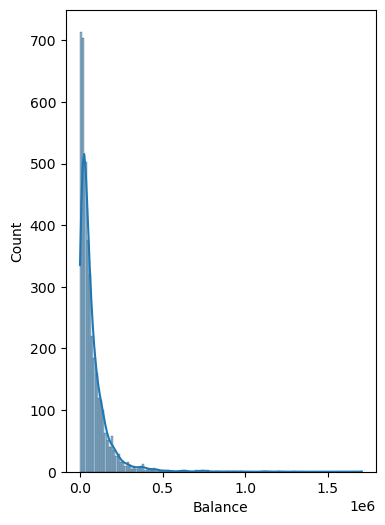

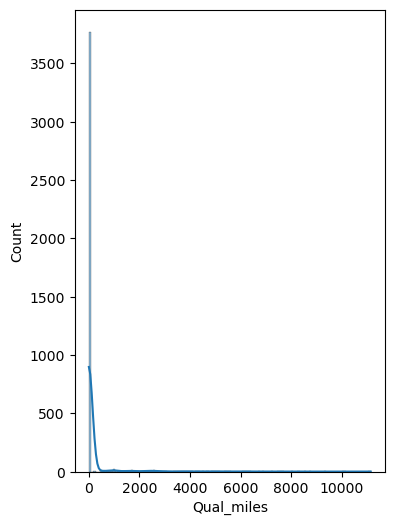

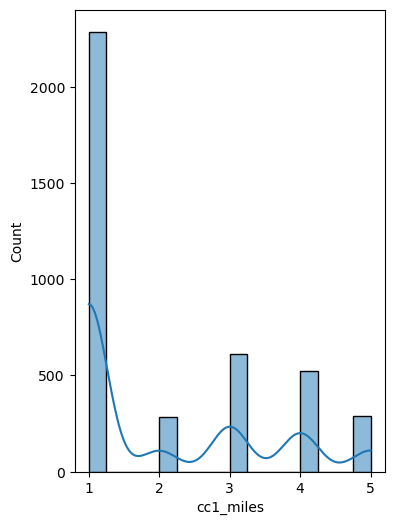

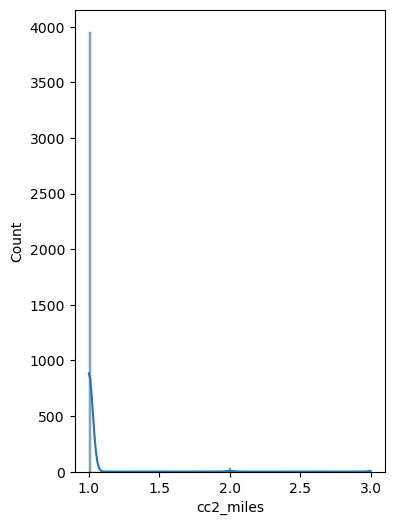

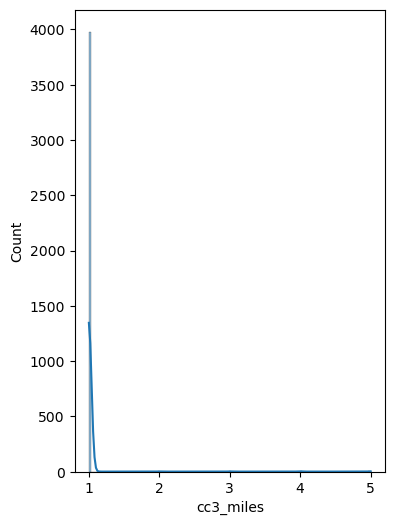

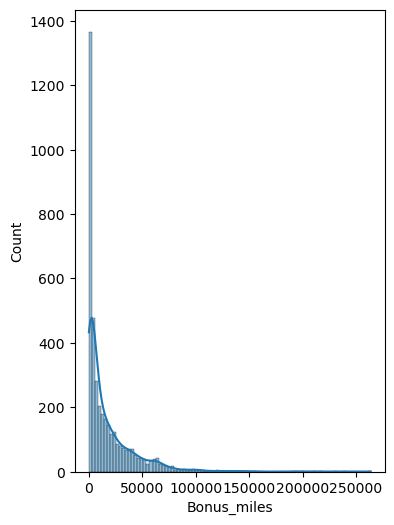

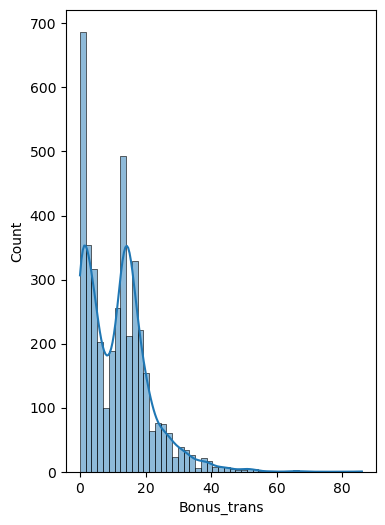

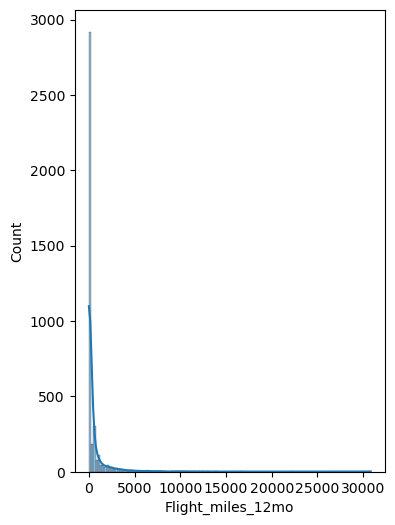

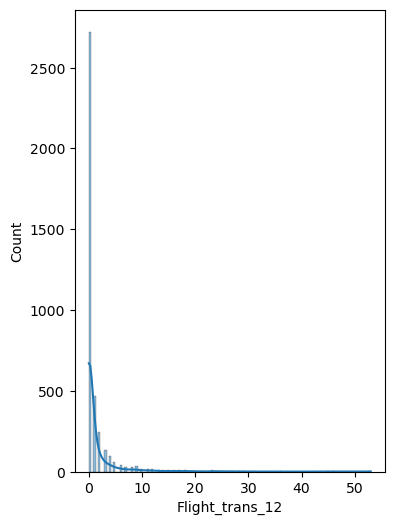

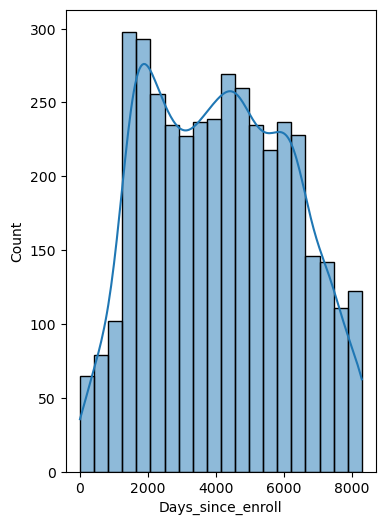

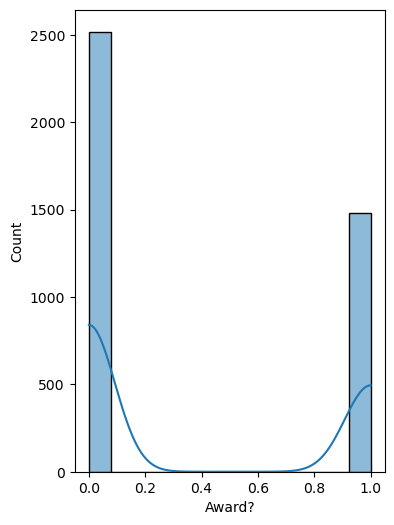

In [91]:
col = [ 'Balance', 'Qual_miles', 'cc1_miles', 'cc2_miles', 'cc3_miles',
       'Bonus_miles', 'Bonus_trans', 'Flight_miles_12mo', 'Flight_trans_12',
       'Days_since_enroll', 'Award?']

for i in col:
    plt.figure(figsize=(4,6))
    sns.histplot(df[i],kde=True)

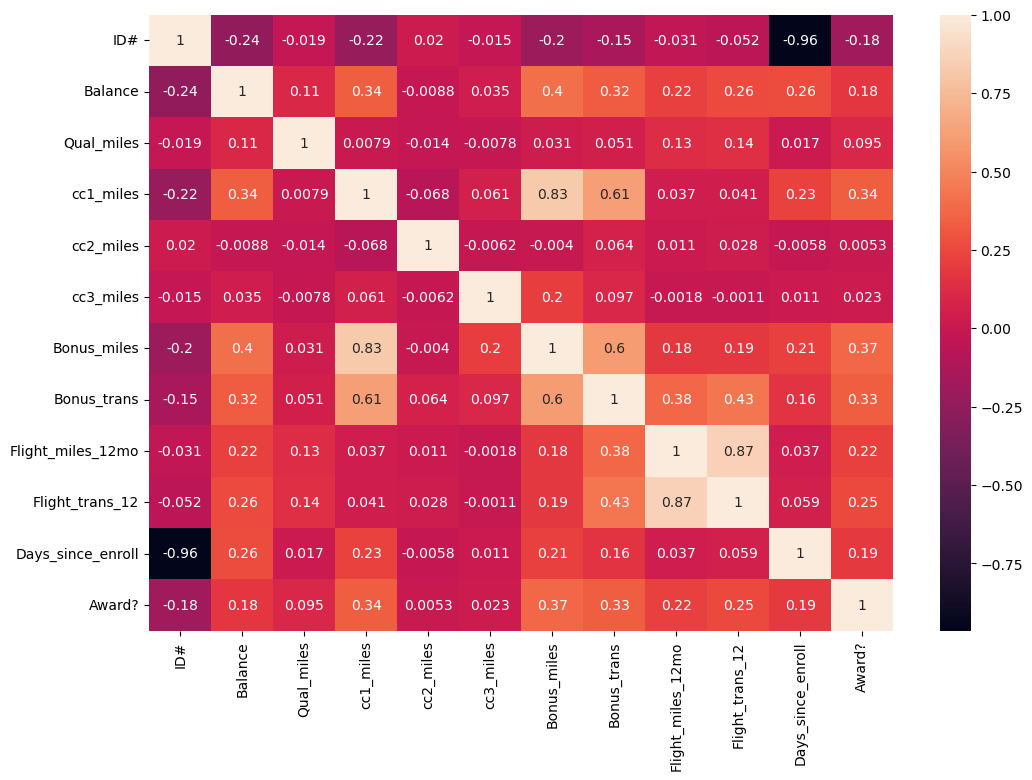

In [12]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [ ]:

sns.pairplot(df,kind='scatter')
plt.show()

# implemention of k clustering

In [13]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [93]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [94]:
inertia = []
k_range = range(1,11)

In [95]:
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)


In [96]:
inertia

[55986.0,
 45564.40660605756,
 38665.796198898985,
 34657.07836550014,
 31029.445586942198,
 27173.23968160324,
 23824.185766649975,
 22551.74463285171,
 20032.833099147047,
 18829.71283390646]

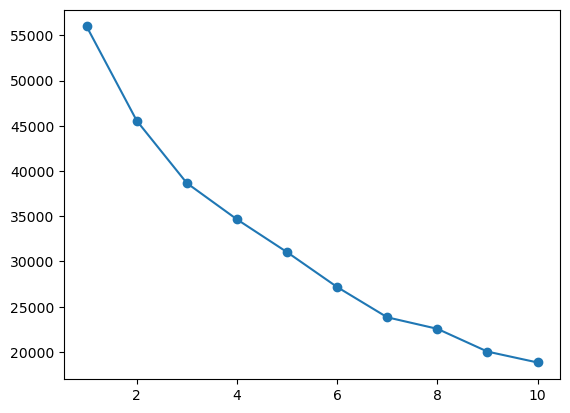

In [97]:
plt.plot(k_range, inertia, marker='o')

In [112]:
kmeans_final = KMeans(n_clusters=6, random_state=42)

In [113]:
cluster_labels = kmeans_final.fit_predict(X_scaled)

In [114]:
df['cluster'] = cluster_labels

In [101]:
df['cluster'].value_counts()

cluster
1    1625
0    1406
2     968
Name: count, dtype: int64

In [102]:
print(cluster_labels)
print(np.unique(cluster_labels))

[0 0 0 ... 1 1 1]
[0 1 2]


In [115]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, cluster_labels)
print(score)

0.33288532511164126


In [116]:
df.groupby('cluster').mean()


,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,dbscan_cluster
cluster,,,,,,,,,,,,,
0,1080.325915,58268.381192,87.093324,1.516152,1.017229,1.000718,7257.793970,8.642498,218.222541,0.664752,5741.268485,0.283561,-0.444365
1,3070.877143,45284.820714,119.220714,1.521429,1.019286,1.000000,8003.081429,9.347857,255.842143,0.751429,2293.243571,0.263571,-1.000000
2,1664.866667,138061.400000,78.800000,3.466667,1.000000,4.066667,93927.866667,28.066667,506.666667,1.600000,4613.866667,0.533333,-1.000000
3,1509.711701,140069.371532,196.394451,4.106152,1.001206,1.002413,49408.817853,20.080820,445.208685,1.340169,5017.626055,0.708082,-1.000000
4,3371.425339,12900.669683,0.000000,1.000000,1.000000,1.000000,145.049774,0.506787,0.000000,0.000000,1579.873303,0.000000,23.176471
5,1642.070922,203727.851064,880.078014,2.248227,1.042553,1.000000,34375.425532,29.007092,5680.297872,16.879433,4851.198582,0.865248,-1.000000


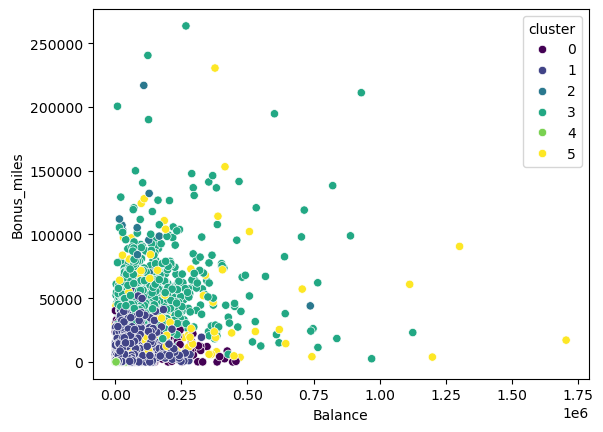

In [117]:
sns.scatterplot(
    x=df['Balance'],
    y=df['Bonus_miles'],
    hue=df['cluster'],
    palette='viridis'
)
plt.show()

####Although the elbow method suggested a possible value of K, different values of K were evaluated using the silhouette score. The highest silhouette score (0.33) was obtained for K = 6, indicating better cluster separation. Therefore, K = 6 was selected for the final KMeans model

In [118]:
from sklearn.metrics import silhouette_score


for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"K={k}: {score:.3f}")

K=2: 0.245
K=3: 0.273
K=4: 0.290
K=5: 0.327
K=6: 0.333
K=7: 0.344
K=8: 0.319
K=9: 0.321
K=10: 0.295


## DB scan

In [119]:
from sklearn.cluster import DBSCAN

In [127]:
df1=pd.read_excel('EastWestAirlines.xlsx',sheet_name="data")

In [128]:
df1.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


In [142]:
df1.drop('ID#',axis=1)

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,dbscan_cluster
0,28143,0,1,1,1,174,1,0,0,7000,0,0
1,19244,0,1,1,1,215,2,0,0,6968,0,0
2,41354,0,1,1,1,4123,4,0,0,7034,0,0
3,14776,0,1,1,1,500,1,0,0,6952,0,0
4,97752,0,4,1,1,43300,26,2077,4,6935,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
3994,18476,0,1,1,1,8525,4,200,1,1403,1,1
3995,64385,0,1,1,1,981,5,0,0,1395,1,1
3996,73597,0,3,1,1,25447,8,0,0,1402,1,1
3997,54899,0,1,1,1,500,1,500,1,1401,0,0


In [143]:
df1.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,dbscan_cluster
0,1,28143,0,1,1,1,174,1,0,0,7000,0,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1,1


In [130]:
scaler = StandardScaler()
X_scaled1 = scaler.fit_transform(df1)

In [131]:
dbscan = DBSCAN(eps=1.5, min_samples=4)
dbscan_labels = dbscan.fit_predict(X_scaled1)

In [132]:
df1['dbscan_cluster'] = dbscan_labels

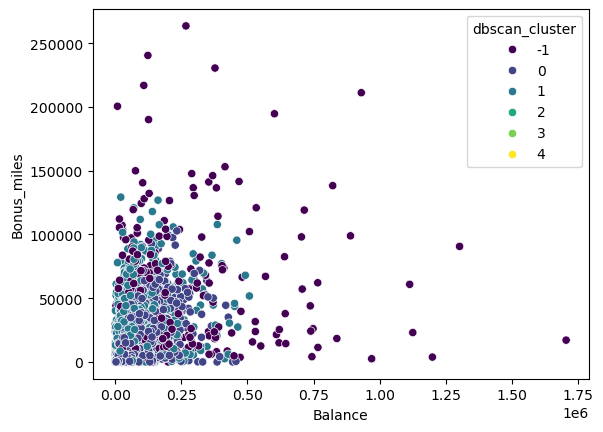

In [138]:
sns.scatterplot(
    data=df1,
    x='Balance',
    y='Bonus_miles',
    hue='dbscan_cluster',
    palette='viridis'
)
plt.show()

In [77]:
print(f"Noise points: {sum(dbscan_labels == -1)}")

Noise points: 333


In [139]:
print(f"Number of clusters: {len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)}")

Number of clusters: 5


In [135]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled1, dbscan_labels)
print(score)

0.2159813854346217


In [144]:
df1.drop(columns='ID#').groupby('dbscan_cluster').mean()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
dbscan_cluster,,,,,,,,,,,
-1,208955.891892,1308.870871,2.741742,1.069069,1.147147,44773.624625,24.903904,2914.720721,8.519520,4789.789790,0.741742
0,56389.088418,33.094230,1.684516,1.000000,1.000000,9576.210461,8.702781,169.641760,0.498962,3802.525944,0.000000
1,71463.320325,49.378862,2.632520,1.000000,1.000000,24625.400000,13.638211,371.905691,1.171545,4575.021951,1.000000
2,38556.733333,0.000000,1.000000,2.000000,1.000000,8951.533333,12.933333,60.000000,0.400000,3390.400000,0.000000
3,36524.250000,0.000000,1.000000,3.000000,1.000000,15518.500000,14.500000,50.000000,0.250000,3179.625000,0.000000
4,34413.500000,0.000000,1.000000,2.000000,1.000000,8967.250000,13.250000,437.500000,1.250000,2816.000000,1.000000


## for dbscan the score is 21% and for KMean it is 33 %